<a href="https://colab.research.google.com/github/lauratpaes/Anna-Clara-_-Laura_-Lavinia/blob/main/tarefa06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#Tarefa 6 - Bioestatítica
## Regressão linear simples e correlação linear de Pearson.
###Anna Clara Tonial 17097091
###Laura Tavares Paes 17097601
###Lavínia Ramos 17081100

###**1- Apresentação dos dados**
#### Os dados utilizados nesta atividade são provenientes do alizado pelo Serviço Florestal Brasileiro (Inventário Florestal Nacional (IFN), reSFB/MMA). Foi utilizada a base de Dados Biofísicos – DAP 10,referente ao estado de São Paulo. O conjunto de dados contém informações sobre indivíduos arbóreos amostrados pelo IFN. Para esta atividade, serão analisadas duas variáveis numéricas: o diâmetro à altura do peito (DAP), em centímetros, e a altura total (HT), em metros.

### **Fonte completa dos dados:** Inventário Florestal Nacional (IFN) – Dados Biofísicos – DAP 10 por UF, estado de São Paulo, versão disponibilizada em setembro de 2025.
### **Link de acesso:** https://dados.florestal.gov.br/pt_BR/dataset/9c54904c-ef67-4406-966f-103f1790d8b9/resource/a5070076-074d-4c36-85e0-c4efd62353f6/download/ifn_dap10_sao_paulo_disp-set2025.xlsx
### **Instituição, autor(a) ou responsável pela base:** Serviço Florestal Brasileiro (SFB), Ministério do Meio Ambiente e Mudança do Clima (MMA).
### **A data de acesso:** 23 de agosto de 2026


In [3]:
import pandas as pd
df = pd.read_excel("tarefa6.xlsx")
pd.set_option('display.max_columns', None)
df.head()


,Lotes,UA,bioma,uf,mun,lon_pc,lat_pc,Subunidade,Subparcela,Data,Sem_arvores_na_UA,Narv,Nfuste,Codigo_medicao,Especie_campo,Codigo_Coleta,Nivel,DAP,DB1,DB2,SA,QF,PS,AFF,HT,HF,PL,HM,HAB,Obs,Tocos,MB,DAP_GRUPO,verbatimIdentification,id_FFB,id_POWO,family,genus,specificEpithet,infraspecificEpithet,scientificName,taxonRank,venacularName,Codigo_coleta
0,SP-01,SP_171,Mata Atlântica,São Paulo,Ribeirão Preto,-47.8800,-21.24,1,6,10/03/2020,N,26,1,SP_171_1_6_26,bocaiuva,SP_171_1_6_26,NaN,28.8,NaN,NaN,1,1,4,N,5.3,4.1,N,S,5,NaN,2,S,DAP10,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,15663.0,NaN,Arecaceae,Acrocomia,aculeata,NaN,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,ESPECIE,NaN,NaN
1,SP-01,SP_223_P1,Mata Atlântica,São Paulo,Matão,-48.5775,-21.60,1,10,07/10/2020,N,26,1,SP_223_P1_1_10_26,macauba,SP_223_P1_1_10_26,NaN,21.5,NaN,NaN,1,1,1,N,10.0,6.5,S,N,5,NaN,0,S,DAP10,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,15663.0,NaN,Arecaceae,Acrocomia,aculeata,NaN,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,ESPECIE,NaN,NaN
2,SP-01,SP_223_P1,Mata Atlântica,São Paulo,Matão,-48.5775,-21.60,4,6,07/10/2020,N,3,1,SP_223_P1_4_6_3,macauba,SP_223_P1_1_10_26,NaN,18.7,NaN,NaN,2,1,1,N,6.5,4.0,N,N,5,NaN,0,N,DAP10,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,15663.0,NaN,Arecaceae,Acrocomia,aculeata,NaN,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,ESPECIE,NaN,NaN
3,SP-01,SP_223_P1,Mata Atlântica,São Paulo,Matão,-48.5775,-21.60,4,8,07/10/2020,N,4,1,SP_223_P1_4_8_4,macauba,SP_223_P1_1_10_26,NaN,19.2,NaN,NaN,2,2,1,N,7.5,6.5,N,N,5,NaN,0,N,DAP10,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,15663.0,NaN,Arecaceae,Acrocomia,aculeata,NaN,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,ESPECIE,NaN,NaN
4,SP-01,SP_253,Mata Atlântica,São Paulo,Ibitinga,-48.7800,-21.78,1,2,19/03/2020,N,10,1,SP_253_1_2_10,bocaiuva,SP_253_1_2_10,NaN,25.9,NaN,NaN,1,1,2,N,10.0,6.5,S,N,5,NaN,0,S,DAP10,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,15663.0,NaN,Arecaceae,Acrocomia,aculeata,NaN,Acrocomia aculeata (Jacq.) Lodd. ex Mart.,ESPECIE,NaN,NaN


In [4]:
borebi = df[df["mun"] == "Borebi"]
analise = borebi[["DAP", "HT"]].dropna()
analise.head()
len(analise)



500

### **2- Gráfico de dispersão**
#### O gráfico de dispersão apresenta a relação entre o diâmetro à altura do peito (DAP), em centímetros, e a altura total (HT), em metros, dos indivíduos arbóreos registrados no município de Borebi, São Paulo.

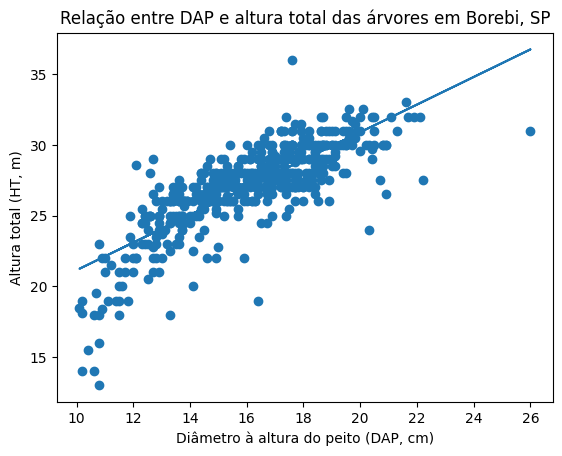

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
regressao = linregress(analise["DAP"], analise["HT"])

plt.scatter(analise["DAP"], analise["HT"])
plt.plot(
    analise["DAP"],
    regressao.intercept + regressao.slope * analise["DAP"]
)

plt.xlabel("Diâmetro à altura do peito (DAP, cm)")
plt.ylabel("Altura total (HT, m)")
plt.title("Relação entre DAP e altura total das árvores em Borebi, SP")

plt.show()

### **3- Regressão Linear Simples**
#### A regressão linear simples é um método estatístico utilizado para descrever e quantificar a relação entre duas variáveis numéricas. Nesse método, uma variável é considerada explicativa (X) e a outra é considerada resposta (Y). A relação entre elas é representada por uma reta.

### **4- Estimação dos dois coeficientes da reta de regressão linear simples**

In [ ]:
from scipy.stats import linregress
regressao = linregress(analise["DAP"], analise["HT"])
print("Intercepto (β₀):", regressao.intercept)
print("Coeficiente angular (β₁):", regressao.slope)

### **5- Interpretação dos coeficientes da regressão**
#### A reta de regressão estimada para os indivíduos de Borebi foi:

$$
HT = 11,3992 + 0,9748(DAP)
$$

O intercepto ($\beta_0 = 11,3992$) representa a altura total estimada quando o DAP é igual a zero. Entretanto, essa situação não possui uma interpretação biológica direta para os indivíduos analisados, sendo o intercepto principalmente um parâmetro matemático do modelo.

O coeficiente angular ($\beta_1 = 0,9748$) indica que, de acordo com o modelo, para cada aumento de 1 cm no DAP, a altura total estimada aumenta, em média, aproximadamente 0,975 m. Como o coeficiente angular é positivo, a relação entre DAP e HT é crescente.


### **7- Correlação linear de Pearson**
A correlação linear de Pearson é uma medida estatística que indica a intensidade e a direção da relação linear entre duas variáveis numéricas. O coeficiente de correlação, representado por $r$, varia de -1 a 1. Valores positivos indicam que as duas variáveis tendem a aumentar juntas, enquanto valores negativos indicam que, quando uma variável aumenta, a outra tende a diminuir. Valores próximos de zero indicam pouca ou nenhuma associação linear entre as variáveis.

In [10]:
r = analise["DAP"].corr(analise["HT"])

print("Coeficiente de correlação de Pearson (r):", r)
display(r)

Coeficiente de correlação de Pearson (r): 0.7917371968161904


np.float64(0.7917371968161904)

### **8- Resultado da correlação de Pearson**

O coeficiente de correlação linear de Pearson obtido para DAP e HT foi $r = 0,7917$. Esse resultado indica uma correlação linear positiva entre as duas variáveis. Portanto, para os indivíduos analisados em Borebi, valores maiores de DAP tendem a estar associados a valores maiores de altura total (HT). O valor de $r$, relativamente próximo de 1, indica uma associação linear positiva relativamente forte entre as variáveis.

### **9- Direção da correlação**

A correlação observada entre o DAP e a altura total (HT) foi positiva ($r = 0,7917$). Isso significa que, nos indivíduos analisados em Borebi, valores maiores de DAP tendem a estar associados a valores maiores de altura total. Portanto, as duas variáveis apresentam uma associação linear positiva.

### **10- Limitação da correlação linear de Pearson**

Uma correlação de Pearson igual ou próxima de zero indica que não há uma relação linear relevante entre as duas variáveis. Entretanto, isso não significa necessariamente que não exista nenhuma relação entre elas. As variáveis podem apresentar outro tipo de associação, como uma relação curva ou não linear, que não seria adequadamente identificada pelo coeficiente de Pearson. Portanto, uma correlação próxima de zero deve ser interpretada como ausência de evidência de uma associação linear, e não como ausência de qualquer relação entre as variáveis.

### **11- Fórmulas utilizadas**

A regressão linear simples é representada pela equação:

$$
\hat{Y} = \beta_0 + \beta_1X
$$

em que $\hat{Y}$ é o valor estimado da variável resposta, $X$ é a variável explicativa, $\beta_0$ é o intercepto e $\beta_1$ é o coeficiente angular.

O coeficiente de correlação linear de Pearson é calculado por:

$$
r = \frac{\sum_{i=1}^{n}(X_i-\bar{X})(Y_i-\bar{Y})}
{\sqrt{\sum_{i=1}^{n}(X_i-\bar{X})^2}\sqrt{\sum_{i=1}^{n}(Y_i-\bar{Y})^2}}
$$

em que $X_i$ e $Y_i$ representam os valores observados das duas variáveis, $\bar{X}$ e $\bar{Y}$ são suas respectivas médias e $n$ é o número de observações.

### **Conclusão**

Os resultados obtidos para os indivíduos arbóreos analisados no município de Borebi, SP, indicaram uma relação linear positiva entre o diâmetro à altura do peito (DAP) e a altura total (HT). O coeficiente de correlação de Pearson foi de $r = 0,7917$, indicando uma associação linear positiva relativamente forte entre as duas variáveis. A regressão linear simples apresentou coeficiente angular de $0,9748$, indicando que, de acordo com o modelo, aumentos no DAP estão associados a aumentos na altura total.

A regressão linear simples e a correlação de Pearson são ferramentas úteis para a interpretação de dados biológicos, pois permitem quantificar e visualizar a relação entre duas variáveis. Enquanto a regressão possibilita representar essa relação por meio de uma reta e estimar valores da variável resposta, a correlação de Pearson permite avaliar a direção e a intensidade da associação linear entre as variáveis. Dessa forma, essas ferramentas podem auxiliar na identificação e interpretação de padrões presentes em conjuntos de dados biológicos.